In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rsem=pd.read_csv("./RNA_DATA/RSEM_results_all/Patient1_2T.genes.results",sep="\t",header=0)
print(rsem.head())

              gene_id                                   transcript_id(s)  \
0  ENSG00000000003.16  ENST00000373020.9,ENST00000494424.1,ENST000004...   
1   ENSG00000000005.6                ENST00000373031.5,ENST00000485971.1   
2  ENSG00000000419.14  ENST00000371582.8,ENST00000371584.9,ENST000003...   
3  ENSG00000000457.14  ENST00000367770.5,ENST00000367771.11,ENST00000...   
4  ENSG00000000460.17  ENST00000286031.10,ENST00000359326.9,ENST00000...   

    length  effective_length  expected_count    TPM   FPKM  
0  3768.00           3671.61            2.00   0.04   0.04  
1   873.50            777.11            0.00   0.00   0.00  
2  1134.53           1038.14          328.95  24.50  21.22  
3  3472.21           3375.82          498.17  11.41   9.88  
4  2400.49           2304.10          179.23   6.01   5.21  


In [3]:
rsem_df=rsem.loc[:,['gene_id','effective_length']]

In [4]:
rsem_df

,gene_id,effective_length
0,ENSG00000000003.16,3671.61
1,ENSG00000000005.6,777.11
2,ENSG00000000419.14,1038.14
3,ENSG00000000457.14,3375.82
4,ENSG00000000460.17,2304.10
...,...,...
78719,ENSG00000310553.1,383.61
78720,ENSG00000310554.1,1070.61
78721,ENSG00000310555.1,357.61
78722,ENSG00000310556.1,753.61


In [5]:
star=pd.read_csv("./RNA_DATA/STAR_results_all/Patient1_2T.ReadsPerGene.out.tab",sep="\t",header=None)
print(star.head(10)) #header=None不要show column names

                   0        1         2         3
0         N_unmapped   443845    443845    443845
1     N_multimapping  3493660   3493660   3493660
2        N_noFeature  4011593  10827569  10927102
3        N_ambiguous  2019101    421840    398235
4  ENSG00000290825.2        0         2         7
5  ENSG00000223972.6        0         0         0
6  ENSG00000310526.1        7         3         4
7  ENSG00000227232.6        0         0         0
8  ENSG00000278267.1        0         0         0
9  ENSG00000243485.6        1         1         0


In [6]:
star_df=star.iloc[4:,0:2].rename(columns={0:'gene_id',1:'raw_count'})

In [7]:
star_df

,gene_id,raw_count
4,ENSG00000290825.2,0
5,ENSG00000223972.6,0
6,ENSG00000310526.1,7
7,ENSG00000227232.6,0
8,ENSG00000278267.1,0
...,...,...
78723,ENSG00000198695.2,6208
78724,ENSG00000210194.1,0
78725,ENSG00000198727.2,64529
78726,ENSG00000210195.2,56


In [8]:
gene_matrix=pd.merge(star_df,rsem_df,how='inner',on='gene_id')

In [9]:
gene_matrix

,gene_id,raw_count,effective_length
0,ENSG00000290825.2,0,1264.98
1,ENSG00000223972.6,0,535.61
2,ENSG00000310526.1,7,712.84
3,ENSG00000227232.6,0,1283.61
4,ENSG00000278267.1,0,0.00
...,...,...,...
78719,ENSG00000198695.2,6208,428.61
78720,ENSG00000210194.1,0,0.00
78721,ENSG00000198727.2,64529,1044.61
78722,ENSG00000210195.2,56,0.00


In [10]:
total_counts = gene_matrix['raw_count'].sum()
#FPKM
gene_matrix['FPKM'] = np.where(
    gene_matrix['effective_length'] > 0,
    gene_matrix['raw_count'] * (10**9)
      / ( total_counts * gene_matrix['effective_length'] ),
    0
)

In [11]:
gene_matrix

,gene_id,raw_count,effective_length,FPKM
0,ENSG00000290825.2,0,1264.98,0.000000
1,ENSG00000223972.6,0,535.61,0.000000
2,ENSG00000310526.1,7,712.84,0.755150
3,ENSG00000227232.6,0,1283.61,0.000000
4,ENSG00000278267.1,0,0.00,0.000000
...,...,...,...,...
78719,ENSG00000198695.2,6208,428.61,1113.824816
78720,ENSG00000210194.1,0,0.00,0.000000
78721,ENSG00000198727.2,64529,1044.61,4750.378744
78722,ENSG00000210195.2,56,0.00,0.000000


In [12]:
# 計算所有基因的 FPKM 總和
sum_fpkm = gene_matrix['FPKM'].sum()

#TPM
# 如果 sum_fpkm 為 0，全部 TPM 設 0；否則按比例計算
if sum_fpkm == 0:
    gene_matrix['TPM'] = 0
else:
    gene_matrix['TPM'] = gene_matrix['FPKM'] / sum_fpkm * 1e6

print(gene_matrix)

                 gene_id  raw_count  effective_length         FPKM  \
0      ENSG00000290825.2          0           1264.98     0.000000   
1      ENSG00000223972.6          0            535.61     0.000000   
2      ENSG00000310526.1          7            712.84     0.755150   
3      ENSG00000227232.6          0           1283.61     0.000000   
4      ENSG00000278267.1          0              0.00     0.000000   
...                  ...        ...               ...          ...   
78719  ENSG00000198695.2       6208            428.61  1113.824816   
78720  ENSG00000210194.1          0              0.00     0.000000   
78721  ENSG00000198727.2      64529           1044.61  4750.378744   
78722  ENSG00000210195.2         56              0.00     0.000000   
78723  ENSG00000210196.2        948              0.00     0.000000   

               TPM  
0         0.000000  
1         0.000000  
2         0.868387  
3         0.000000  
4         0.000000  
...            ...  
78719  1280.

In [13]:
import os
def calculate_FPKM_TPM(sample,rsem,star):
    rsem_df=rsem.loc[:,['gene_id','effective_length']]
    star_df=star.iloc[4:,0:2].rename(columns={0:'gene_id',1:'raw_count'})
    gene_matrix=pd.merge(star_df,rsem_df,how='inner',on='gene_id')
    total_counts = gene_matrix['raw_count'].sum()
    
    #FPKM
    gene_matrix['FPKM'] = np.where(
    gene_matrix['effective_length'] > 0,
    gene_matrix['raw_count'] * (10**9)
      / ( total_counts * gene_matrix['effective_length'] ),
    0
    )
    # 計算所有基因的 FPKM 總和
    sum_fpkm = gene_matrix['FPKM'].sum()

    #TPM
    # 如果 sum_fpkm 為 0，全部 TPM 設 0；否則按比例計算
    if sum_fpkm == 0:
      gene_matrix['TPM'] = 0
    else:
      gene_matrix['TPM'] = gene_matrix['FPKM'] / sum_fpkm * 1e6

    out_dir='./RNA_DATA/FPKM_TPM_results_all'
    out_file = os.path.join(out_dir, f'{sample}_FPKM_TPM.csv')
    gene_matrix.to_csv(out_file,index=False)
    return gene_matrix


In [14]:
#測試
rsem=pd.read_csv("./RNA_DATA/RSEM_results_all/Patient10_2T.genes.results",sep="\t",header=0)
star=pd.read_csv("./RNA_DATA/STAR_results_all/Patient10_2T.ReadsPerGene.out.tab",sep="\t",header=None)
sample='Patient10_2T'
calculate_FPKM_TPM(sample,rsem,star)

,gene_id,raw_count,effective_length,FPKM,TPM
0,ENSG00000290825.2,0,1525.41,0.000000,0.000000
1,ENSG00000223972.6,0,534.24,0.000000,0.000000
2,ENSG00000310526.1,1,633.95,0.191709,0.241039
3,ENSG00000227232.6,0,1282.24,0.000000,0.000000
4,ENSG00000278267.1,0,0.00,0.000000,0.000000
...,...,...,...,...,...
78719,ENSG00000198695.2,8719,427.24,2480.235018,3118.435076
78720,ENSG00000210194.1,0,0.00,0.000000,0.000000
78721,ENSG00000198727.2,58388,1043.24,6802.012606,8552.268050
78722,ENSG00000210195.2,2,0.00,0.000000,0.000000


### 一次讀入所有RSEM+STAR檔並輸出FPKM_TPM.csv

In [ ]:
import glob
# 目錄設定
rsem_dir = './RNA_DATA/RSEM_results_all'
star_dir = './RNA_DATA/STAR_results_all'

# 找到所有 RSEM 結果檔
rsem_files = glob.glob(os.path.join(rsem_dir, '*.genes.results'))

for rsem_path in rsem_files:
    # 從檔名擷取 sample 名稱
    sample = os.path.basename(rsem_path).replace('.genes.results', '')

    # 對應的 STAR 檔路徑
    star_path = os.path.join(star_dir, f'{sample}.ReadsPerGene.out.tab')
    if not os.path.exists(star_path):
        print(f'⚠️ 找不到 STAR 檔: {star_path}，跳過 {sample}')
        continue

    # 讀入
    rsem = pd.read_csv(rsem_path, sep='\t', header=0)
    star = pd.read_csv(star_path, sep='\t', header=None)

    # 計算並輸出
    calculate_FPKM_TPM(sample, rsem, star)

In [ ]:
import pandas as pd
import os
folder_path="./RNA_DATA/STAR_results_all/"
files = [f for f in os.listdir(folder_path)]
gene_sample_df=[]

for file in files:
    sample = os.path.basename(file).replace('.ReadsPerGene.out.tab', '')
    file_path=os.path.join(folder_path,file)
    df=pd.read_csv(file_path,sep="\t",header=None)

    df=df.iloc[4:,0:2].rename(columns={0:'gene_id',1:sample}) #取"gene_id","raw count"
    gene_sample_df.append(df)

#根據gene_id做合併
from functools import reduce
Raw_count_merged = reduce(lambda left, right: pd.merge(left, right, on="gene_id"), gene_sample_df)

In [ ]:
#Raw_count_merged.to_csv('./RNA_DATA/Raw_count_merged_matrix.csv',index=False)

### 讀入所有FPKM_TPM.csv，並合併成一個Matrix

In [72]:
import pandas as pd
folder_path="./RNA_DATA/FPKM_TPM_results_all/"
files = [f for f in os.listdir(folder_path)]
gene_sample_df=[]

for file in files:
    sample = os.path.basename(file).replace('_FPKM_TPM.csv', '')
    file_path=os.path.join(folder_path,file)
    df=pd.read_csv(file_path)

    df=df[["gene_id","TPM"]].copy() #取"gene_id","TPM"
    df.rename(columns={"TPM":sample},inplace=True) 

    gene_sample_df.append(df)

#根據gene_id做合併
from functools import reduce
merged_df = reduce(lambda left, right: pd.merge(left, right, on="gene_id"), gene_sample_df)

In [73]:
merged_df

,gene_id,Patient10_2T,Patient1_2T,Patient2_2T,Patient3_5T,Patient4_3T,Patient5_3T,Patient6_4T,Patient7_2T,Patient8_1T,...,SRR17386549,SRR17386550,SRR17386551,SRR17386552,SRR17386553,SRR17386554,SRR17386555,SRR17386556,SRR17386557,SRR17386558
0,ENSG00000290825.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,ENSG00000223972.6,0.000000,0.000000,0.000000,0.000000,0.239811,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSG00000310526.1,0.241039,0.868387,0.409852,1.053096,1.782697,0.000000,1.157613,1.838390,1.707287,...,0.000000,1.234439,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,ENSG00000227232.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,ENSG00000278267.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78719,ENSG00000198695.2,3118.435076,1280.845158,2492.313301,2592.823022,1559.430102,3076.328365,3124.909961,1249.979559,2626.774563,...,771.274994,892.750132,867.387453,683.881197,1129.260875,813.596261,884.405723,924.709438,1273.730736,729.505163
78720,ENSG00000210194.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,888.528227,958.052635,1225.521303,757.306561,705.757173,222.780368,1593.082395,932.700018,2219.474838,378.565208
78721,ENSG00000198727.2,8552.268050,5462.707890,8472.888620,6920.669500,8016.649732,10520.205628,7299.094380,4952.923936,10006.202800,...,1601.242184,2372.905325,2566.576815,1949.489331,3797.428408,1898.134049,2541.929434,2718.200308,2751.612699,2348.817826
78722,ENSG00000210195.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9187.943952,6396.727560,7698.448568,7842.476188,2924.576486,9581.027960,8530.969302,9499.581403,9868.796113,5512.589988


In [ ]:
#merged_df.to_csv("./RNA_DATA/TPM_gene_samples_matrix.csv",index=False)

In [74]:
merged_df.shape

(78724, 22)

In [75]:
#filter column
t_columns = [col for col in merged_df.columns if 'T' in col]
n_columns = [col for col in merged_df.columns if 'SRR' in col]

In [76]:
t_df = merged_df[['gene_id'] + t_columns]
n_df = merged_df[['gene_id'] + n_columns]

In [77]:
gene_matrix=pd.merge(n_df,t_df,on='gene_id',how='outer') #outer-> row 聯集
gene_matrix_T=gene_matrix.set_index('gene_id').T
gene_matrix_T

gene_id,ENSG00000000003.16,ENSG00000000005.6,ENSG00000000419.14,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.17,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.15,...,ENSG00000310548.1,ENSG00000310549.1,ENSG00000310550.1,ENSG00000310551.1,ENSG00000310552.1,ENSG00000310553.1,ENSG00000310554.1,ENSG00000310555.1,ENSG00000310556.1,ENSG00000310557.1
SRR17386548,0.129953,0.0,6.428580,0.616464,0.203464,29.288374,0.212685,2.075125,2.793789,0.950791,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386549,0.075040,0.0,5.803530,0.711938,0.553893,27.909930,0.000000,2.105781,0.681042,0.316494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386550,0.174424,0.0,10.785201,1.654917,0.451634,55.427278,1.093084,2.228049,1.218993,1.996892,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386551,0.139931,0.0,9.472061,1.327593,0.362317,58.917343,0.839337,3.189250,1.397049,0.590185,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386552,0.000000,0.0,4.700903,1.128508,0.128289,51.620346,2.745549,2.228199,2.004233,1.232283,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386553,0.000000,0.0,11.676480,0.977174,0.430032,62.126005,0.691596,3.289420,2.382414,1.158415,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386554,0.000000,0.0,9.981199,1.472511,0.334795,54.315599,0.570689,3.772122,1.983299,0.797998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386555,0.000000,0.0,10.171305,1.246866,2.254609,47.689534,0.000000,2.896616,0.966042,1.204495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386556,0.000000,0.0,10.524596,1.079448,0.830575,36.807427,1.306342,2.403401,2.806784,0.697993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386557,0.000000,0.0,11.489995,1.588561,0.924803,65.956970,0.000000,4.562624,1.753119,0.968501,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
gene_matrix_log=np.log2(gene_matrix_T+1)
gene_matrix_log

gene_id,ENSG00000000003.16,ENSG00000000005.6,ENSG00000000419.14,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.17,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.15,...,ENSG00000310548.1,ENSG00000310549.1,ENSG00000310550.1,ENSG00000310551.1,ENSG00000310552.1,ENSG00000310553.1,ENSG00000310554.1,ENSG00000310555.1,ENSG00000310556.1,ENSG00000310557.1
SRR17386548,0.176263,0.0,2.893086,0.692841,0.267193,4.920692,0.278205,1.620645,1.923640,0.964059,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386549,0.104391,0.0,2.766284,0.775630,0.635887,4.853493,0.000000,1.634956,0.749356,0.396701,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386550,0.231954,0.0,3.558905,1.408667,0.537678,5.818321,1.065630,1.690662,1.149905,1.583467,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386551,0.188947,0.0,3.388474,1.218839,0.446063,5.904902,0.879186,2.066692,1.261260,0.669195,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386552,0.000000,0.0,2.511190,1.089843,0.174137,5.717549,1.905177,1.690729,1.586997,1.158520,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386553,0.000000,0.0,3.664082,0.983440,0.516047,5.980163,0.758385,2.100782,1.758053,1.109972,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386554,0.000000,0.0,3.456964,1.305977,0.416618,5.789614,0.651398,2.254631,1.576909,0.846391,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386555,0.000000,0.0,3.481726,1.167914,1.702484,5.605540,0.000000,1.962222,0.975294,1.140448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386556,0.000000,0.0,3.526644,1.056201,0.872297,5.240598,1.205606,1.766977,1.928573,0.763831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR17386557,0.000000,0.0,3.642701,1.372150,0.944711,6.065162,0.000000,2.475765,1.461067,0.977097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
gene_matrix_log.index.name = 'sample'  # 把 index 命名為 'sample'
gene_matrix_log_reset = gene_matrix_log.reset_index()  # 讓 sample 變成一欄

In [86]:
gene_matrix_log_reset 

gene_id,sample,ENSG00000000003.16,ENSG00000000005.6,ENSG00000000419.14,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.17,ENSG00000001036.14,ENSG00000001084.13,...,ENSG00000310548.1,ENSG00000310549.1,ENSG00000310550.1,ENSG00000310551.1,ENSG00000310552.1,ENSG00000310553.1,ENSG00000310554.1,ENSG00000310555.1,ENSG00000310556.1,ENSG00000310557.1
0,SRR17386548,0.176263,0.0,2.893086,0.692841,0.267193,4.920692,0.278205,1.620645,1.923640,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR17386549,0.104391,0.0,2.766284,0.775630,0.635887,4.853493,0.000000,1.634956,0.749356,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR17386550,0.231954,0.0,3.558905,1.408667,0.537678,5.818321,1.065630,1.690662,1.149905,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR17386551,0.188947,0.0,3.388474,1.218839,0.446063,5.904902,0.879186,2.066692,1.261260,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR17386552,0.000000,0.0,2.511190,1.089843,0.174137,5.717549,1.905177,1.690729,1.586997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,SRR17386553,0.000000,0.0,3.664082,0.983440,0.516047,5.980163,0.758385,2.100782,1.758053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,SRR17386554,0.000000,0.0,3.456964,1.305977,0.416618,5.789614,0.651398,2.254631,1.576909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,SRR17386555,0.000000,0.0,3.481726,1.167914,1.702484,5.605540,0.000000,1.962222,0.975294,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,SRR17386556,0.000000,0.0,3.526644,1.056201,0.872297,5.240598,1.205606,1.766977,1.928573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,SRR17386557,0.000000,0.0,3.642701,1.372150,0.944711,6.065162,0.000000,2.475765,1.461067,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
#melt 把"寬"格式-> "長"格式
gene_matrix_log_new=gene_matrix_log_reset.melt(id_vars='sample', #哪一欄保持不變
                                                      var_name='gene', #取原始欄位的名稱為gene
                                                      value_name='log2_count') #每個欄位對應sample的數值

In [81]:
gene_matrix_log_new

,sample,gene,log2_count
0,SRR17386548,ENSG00000000003.16,0.176263
1,SRR17386549,ENSG00000000003.16,0.104391
2,SRR17386550,ENSG00000000003.16,0.231954
3,SRR17386551,ENSG00000000003.16,0.188947
4,SRR17386552,ENSG00000000003.16,0.000000
...,...,...,...
1653199,Patient5_3T,ENSG00000310557.1,0.000000
1653200,Patient6_4T,ENSG00000310557.1,0.000000
1653201,Patient7_2T,ENSG00000310557.1,0.000000
1653202,Patient8_1T,ENSG00000310557.1,0.000000


In [82]:
gene_matrix_log_new['Group']=gene_matrix_log_new['sample'].apply(lambda x:"Control" if 'SRR' in x else 'NMOSD')

In [83]:
gene_matrix_log_new

,sample,gene,log2_count,Group
0,SRR17386548,ENSG00000000003.16,0.176263,Control
1,SRR17386549,ENSG00000000003.16,0.104391,Control
2,SRR17386550,ENSG00000000003.16,0.231954,Control
3,SRR17386551,ENSG00000000003.16,0.188947,Control
4,SRR17386552,ENSG00000000003.16,0.000000,Control
...,...,...,...,...
1653199,Patient5_3T,ENSG00000310557.1,0.000000,NMOSD
1653200,Patient6_4T,ENSG00000310557.1,0.000000,NMOSD
1653201,Patient7_2T,ENSG00000310557.1,0.000000,NMOSD
1653202,Patient8_1T,ENSG00000310557.1,0.000000,NMOSD


In [92]:
gene_matrix_log_new['log2_count'].describe()

count    1.653204e+06
mean     7.128315e-01
std      1.574444e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.810393e-01
max      1.847788e+01
Name: log2_count, dtype: float64

            count      mean       std  min  25%  50%       75%        max
Group                                                                    
Control  865964.0  0.550971  1.343303  0.0  0.0  0.0  0.000000  18.477878
NMOSD    787240.0  0.890878  1.777698  0.0  0.0  0.0  0.803315  16.267839


C:\Users\JANE\AppData\Local\Temp\ipykernel_3932\3246339102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


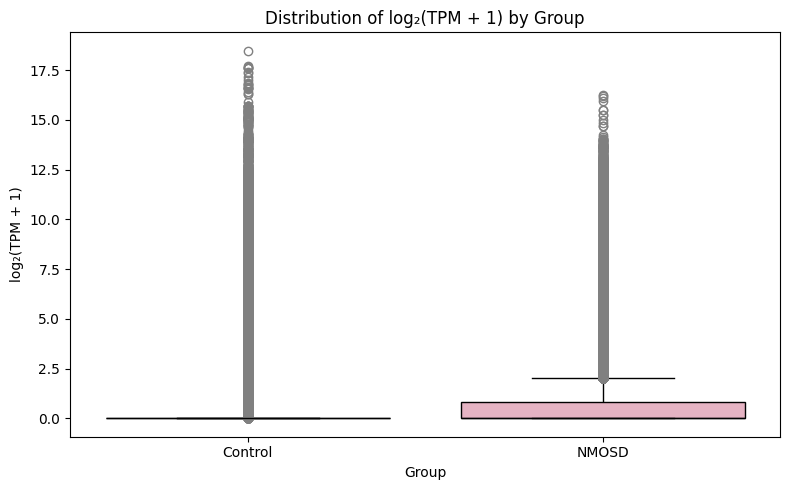

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 分組 summary statistics（不變）
summary = gene_matrix_log_new.groupby('Group')['log2_count'] \
           .describe()[['count','mean','std','min','25%','50%','75%','max']]
print(summary)

# 2. Seaborn 箱型圖
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Group',
    y='log2_count',
    data=gene_matrix_log_new,
    palette={'Control': '#AC9BEA', 'NMOSD': '#EDABC0'},
    showfliers=True,      # True 顯示離群點，False 隱藏
    boxprops={'edgecolor':'black'},
    medianprops={'color':'black'},
    whiskerprops={'color':'black'}, #whiskers（箱線圖伸出來那兩條線）
    capprops={'color':'black'}, #whiskers 末端那兩個小橫槓
    flierprops={'markeredgecolor':'gray'} #離群點
)

plt.ylabel('log₂(TPM + 1)')
plt.title('Distribution of log₂(TPM + 1) by Group')
plt.tight_layout()
plt.show()


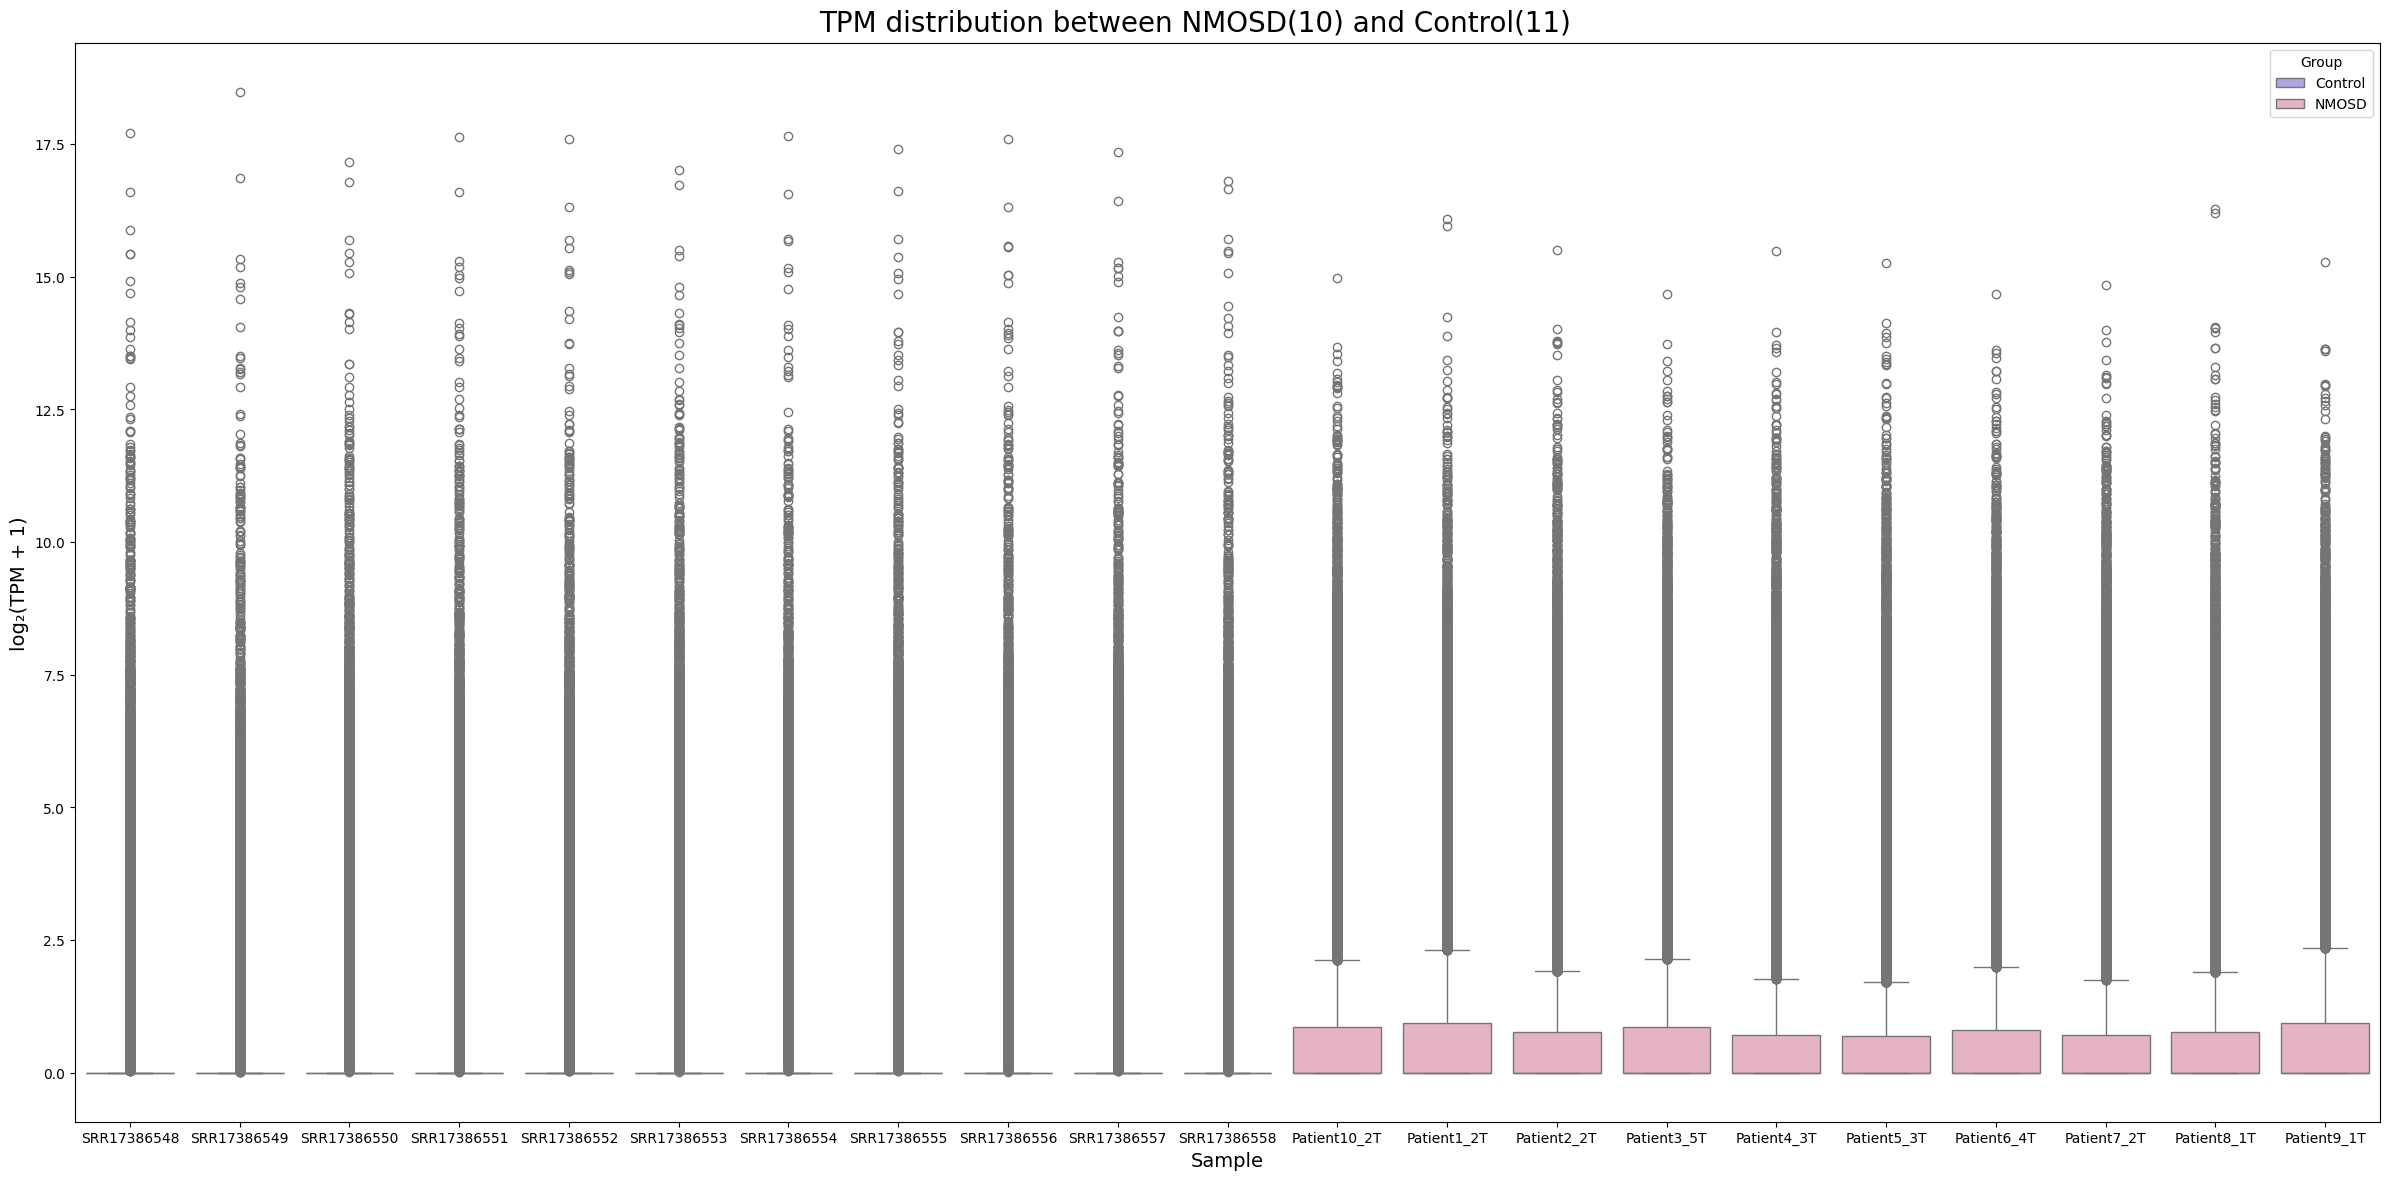

In [84]:
plt.figure(figsize=(24,12))
sns.boxplot(x='sample',y='log2_count',hue='Group',data=gene_matrix_log_new, palette={'Control': '#AC9BEA', 'NMOSD': '#EDABC0'})
plt.suptitle('TPM distribution between NMOSD(10) and Control(11)',fontsize=20)
plt.xlabel("Sample", size=14)
plt.ylabel("log₂(TPM + 1)",size=14)
plt.tight_layout()
plt.show()